# 第 9 章　人工神經網路（ANN）基礎 — 實作 Notebook

「醫學生的機器學習入門」第 9 章配套程式。建議在 **Google Colab** 執行（選單「執行階段 → 全部執行」即可）；本機 Jupyter 也可以。

- 第 1–4 節：用 scikit-learn 的 `MLPClassifier` 在乳癌資料（WDBC）上訓練神經網路，只需要 Colab 預裝套件。
- 第 5 節（進階）：用 Keras 3 在胸部 X 光小圖（PneumoniaMNIST）上訓練。**沒有安裝 Keras 的環境會自動跳過這一節**，不會報錯。

本 notebook 的醫學資料皆為公開教學資料集，結果僅供學習，不構成臨床建議。

## 0. 環境檢查
先印出套件版本，並固定隨機種子讓結果可以重現。

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib
import matplotlib.pyplot as plt

print("numpy", np.__version__, "| pandas", pd.__version__,
      "| scikit-learn", sklearn.__version__, "| matplotlib", matplotlib.__version__)
RS = 42

numpy 2.1.3 | pandas 2.2.3 | scikit-learn 1.6.1 | matplotlib 3.10.0


## 1. 一個神經元：加權總和 + 活化函數
一個人工神經元做兩件事：把輸入乘上權重後加總（再加偏差 b），然後丟進活化函數。下面用 NumPy 手算一次。

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

x = np.array([1.2, -0.5, 2.0])      # three standardized inputs
w = np.array([0.8, 0.3, 1.1])       # weights
b = -1.5                            # bias

z = x @ w + b                       # weighted sum
print(f"weighted sum z = {z:.3f}")
print(f"sigmoid(z) = {sigmoid(z):.3f}  (probability-like, between 0 and 1)")
print(f"relu(z)    = {relu(z):.3f}")

weighted sum z = 1.510
sigmoid(z) = 0.819  (probability-like, between 0 and 1)
relu(z)    = 1.510


z 是加權總和；sigmoid 把它壓到 0～1，可以解讀成機率——這其實就是第 4 章的邏輯迴歸。

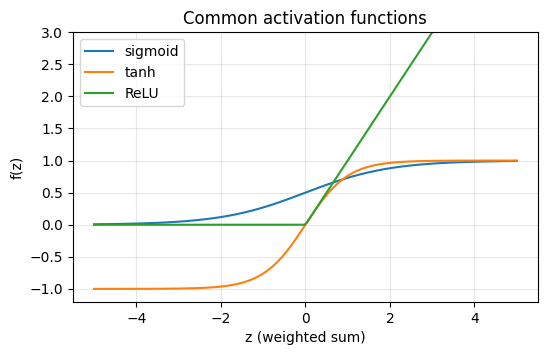

In [3]:
zz = np.linspace(-5, 5, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(zz, sigmoid(zz), label="sigmoid")
ax.plot(zz, np.tanh(zz), label="tanh")
ax.plot(zz, relu(zz), label="ReLU")
ax.set_ylim(-1.2, 3)
ax.set_xlabel("z (weighted sum)")
ax.set_ylabel("f(z)")
ax.set_title("Common activation functions")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

三條曲線都是「非線性」的，這正是神經網路能畫出彎曲決策邊界的關鍵。

## 2. 為什麼需要隱藏層：XOR 問題
我們造一份「對角線同類」的資料（XOR）。邏輯迴歸只能畫一條直線，加了隱藏層的神經網路則可以把平面切成好幾塊。

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

rng = np.random.default_rng(RS)
centers = np.array([[0, 0], [1, 1], [0, 1], [1, 0]], dtype=float)
X_xor = np.vstack([c + rng.normal(0, 0.13, size=(60, 2)) for c in centers])
y_xor = np.repeat([0, 0, 1, 1], 60)

logit = LogisticRegression().fit(X_xor, y_xor)
mlp_xor = MLPClassifier(hidden_layer_sizes=(8,), max_iter=3000, random_state=RS).fit(X_xor, y_xor)
print(f"Logistic regression training accuracy: {logit.score(X_xor, y_xor):.2f}")
print(f"MLP (8 hidden neurons) training accuracy: {mlp_xor.score(X_xor, y_xor):.2f}")

Logistic regression training accuracy: 0.50
MLP (8 hidden neurons) training accuracy: 1.00


邏輯迴歸大約只有五成（跟亂猜一樣），神經網路接近 100%。畫出決策邊界更清楚：

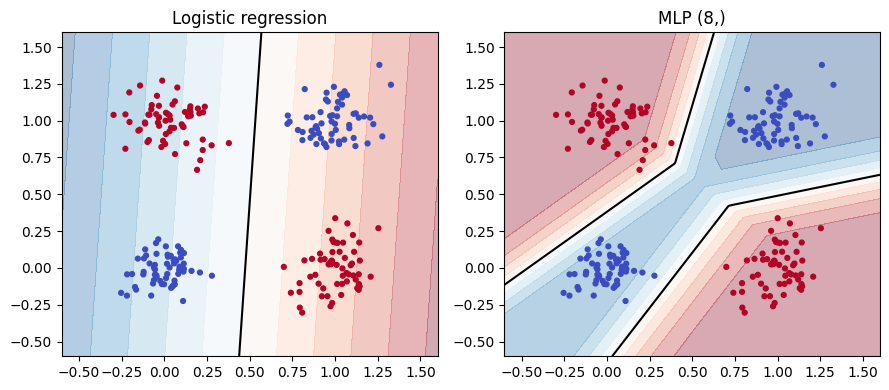

In [5]:
xx, yy = np.meshgrid(np.linspace(-0.6, 1.6, 200), np.linspace(-0.6, 1.6, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (name, m) in zip(axes, [("Logistic regression", logit), ("MLP (8,)", mlp_xor)]):
    p = m.predict_proba(grid)[:, 1].reshape(xx.shape)
    ax.contourf(xx, yy, p, levels=10, cmap="RdBu_r", alpha=0.35)
    ax.contour(xx, yy, p, levels=[0.5], colors="k")
    ax.scatter(*X_xor.T, c=y_xor, cmap="coolwarm", s=12)
    ax.set_title(name)
plt.tight_layout()
plt.show()

黑線是模型的分類界線（預測機率 = 0.5）。只有加了隱藏層的網路能把四團點正確分開。

## 3. 表格資料實戰：WDBC 乳癌資料
資料來自 scikit-learn 內建的 Breast Cancer Wisconsin (Diagnostic)，569 筆、30 個細胞核影像特徵。
**注意：sklearn 版的 target 0 = malignant（惡性）、1 = benign（良性）**，先印出來確認。

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

X, y = load_breast_cancer(return_X_y=True, as_frame=True)
print(X.shape, "| target_names:", load_breast_cancer().target_names)
print(y.value_counts().rename({0: "malignant(0)", 1: "benign(1)"}))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RS)

(569, 30) | target_names: ['malignant' 'benign']
target
benign(1)       357
malignant(0)    212
Name: count, dtype: int64


先切訓練集與測試集（分層抽樣保持良惡性比例），測試集要留到最後才看。

### 3.1 用 Pipeline 訓練 MLPClassifier
神經網路用梯度下降學習，對特徵尺度很敏感，所以一定先標準化。這裡用兩個隱藏層（16 與 8 個神經元）。
不使用 `early_stopping=True`：在這份小資料上它常常太早停下來，模型幾乎沒學到東西。

In [7]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix

mlp = make_pipeline(
    StandardScaler(),
    MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=RS),
)
mlp.fit(X_train, y_train)

net = mlp[-1]
print("iterations used (n_iter_):", net.n_iter_)
print(f"test accuracy: {mlp.score(X_test, y_test):.4f}")
proba_malignant = mlp.predict_proba(X_test)[:, 0]          # column 0 = malignant
print(f"test AUC (malignant as positive): {roc_auc_score(y_test == 0, proba_malignant):.4f}")
print("confusion matrix (rows = true [malignant, benign]):")
print(confusion_matrix(y_test, mlp.predict(X_test)))

iterations used (n_iter_): 345
test accuracy: 0.9561
test AUC (malignant as positive): 0.9940
confusion matrix (rows = true [malignant, benign]):
[[41  1]
 [ 4 68]]


準確率約 0.96。混淆矩陣第一列是真正惡性的病例：被判成良性的那一格就是偽陰性，臨床上代價最高。

### 3.2 網路裡到底有多少參數？

In [8]:
n_params = sum(W.size for W in net.coefs_) + sum(b.size for b in net.intercepts_)
for i, W in enumerate(net.coefs_):
    print(f"layer {i}: weight matrix {W.shape}")
print("total trainable parameters:", n_params)

layer 0: weight matrix (30, 16)
layer 1: weight matrix (16, 8)
layer 2: weight matrix (8, 1)
total trainable parameters: 641


30×16 + 16×8 + 8×1 個權重，再加上每個神經元一個偏差，總共 641 個參數——比訓練資料的 455 筆還多，這就是神經網路容易過擬合的原因之一。

### 3.3 不標準化會怎樣？

In [9]:
raw = MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=RS)
raw.fit(X_train, y_train)
print(f"without scaling: test accuracy = {raw.score(X_test, y_test):.4f}")
print(f"with scaling:    test accuracy = {mlp.score(X_test, y_test):.4f}")

without scaling: test accuracy = 0.9298
with scaling:    test accuracy = 0.9561


沒標準化時準確率明顯下降：有些特徵（如面積）數值上千，有些不到 1，梯度下降會被大尺度的特徵牽著走。

### 3.4 看訓練損失曲線
`loss_curve_` 記錄每個 epoch（把訓練資料看完一遍）後的損失。

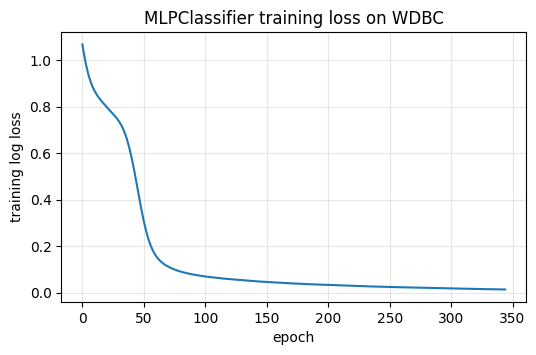

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(net.loss_curve_)
ax.set_xlabel("epoch")
ax.set_ylabel("training log loss")
ax.set_title("MLPClassifier training loss on WDBC")
ax.grid(alpha=0.3)
plt.show()

損失一路下降代表模型在「背熟」訓練資料；但光看訓練損失無法判斷有沒有過擬合，要搭配驗證資料（第 5 節的 Keras 會示範）。

### 3.5 正則化強度 alpha 與網路大小
`alpha` 是 L2 正則化強度：越大越懲罰過大的權重。用 5 折交叉驗證比較幾種設定（只在訓練集上做）。

In [11]:
from sklearn.model_selection import cross_val_score

settings = [((4,), 1e-4), ((16, 8), 1e-4), ((128, 128), 1e-4), ((128, 128), 1.0)]
for hidden, alpha in settings:
    pipe = make_pipeline(StandardScaler(),
                         MLPClassifier(hidden_layer_sizes=hidden, alpha=alpha,
                                       max_iter=1000, random_state=RS))
    s = cross_val_score(pipe, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"hidden={str(hidden):10s} alpha={alpha:<7g} CV AUC = {s.mean():.4f} ± {s.std():.4f}")

hidden=(4,)       alpha=0.0001  CV AUC = 0.9922 ± 0.0109


hidden=(16, 8)    alpha=0.0001  CV AUC = 0.9943 ± 0.0056


hidden=(128, 128) alpha=0.0001  CV AUC = 0.9924 ± 0.0104


hidden=(128, 128) alpha=1       CV AUC = 0.9948 ± 0.0084


在這份資料上各種設定的差距都很小（落在彼此的標準差之內），表示「網路越大越好」並不成立。

### 3.6 神經網路一定比較好嗎？
同樣用 5 折交叉驗證，拿邏輯迴歸與隨機森林當對照。

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

models = {
    "Logistic regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    "Random forest": RandomForestClassifier(n_estimators=300, random_state=RS),
    "MLP (16, 8)": make_pipeline(StandardScaler(),
                                 MLPClassifier(hidden_layer_sizes=(16, 8), max_iter=1000, random_state=RS)),
}
for name, m in models.items():
    s = cross_val_score(m, X_train, y_train, cv=5, scoring="roc_auc")
    print(f"{name:20s} CV AUC = {s.mean():.4f} ± {s.std():.4f}")

Logistic regression  CV AUC = 0.9935 ± 0.0108


Random forest        CV AUC = 0.9867 ± 0.0158


MLP (16, 8)          CV AUC = 0.9943 ± 0.0056


三者的 AUC 都在 0.98–0.99 附近、差距小於標準差。這種小型表格資料，神經網路沒有明顯優勢，卻更難解釋、更需要調參數。

## 4. 小結（sklearn 部分）
- `MLPClassifier` 用法跟前面各章的模型一樣：`fit`、`predict`、`predict_proba`、放進 `Pipeline`。
- 一定要標準化；不要用 `early_stopping=True`（入門階段）；看 `n_iter_` 確認有沒有真的訓練。

## 5. 進階：Keras 3 + 胸部 X 光（PneumoniaMNIST）
PneumoniaMNIST 是 MedMNIST v2 的子集（CC BY 4.0），把小兒胸部 X 光縮成 **28×28 像素**的灰階小圖，標籤為正常（0）／肺炎（1）。
我們直接從 Zenodo 下載官方 `.npz` 檔（約 4 MB），用 NumPy 讀取，不需要安裝 medmnist 或 PyTorch。

先檢查 Keras 是否可用。Colab 已預裝 Keras 3；本機沒有的話，這一節會自動跳過。

In [13]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"   # must be set before importing keras
try:
    import keras
    print("keras", keras.__version__, "| backend:", keras.backend.backend())
except ImportError:
    keras = None
    print("Keras is not installed in this environment -> section 5 training will be skipped.")
    print("Run this notebook on Google Colab to try it, or `pip install tensorflow keras` locally.")

keras 3.13.2 | backend: tensorflow


接著下載資料（已下載過就直接讀本機檔案）。網路失敗時會印出清楚的錯誤訊息，而不是讓整本 notebook 中斷。

In [14]:
import urllib.request

NPZ_URL = "https://zenodo.org/records/10519652/files/pneumoniamnist.npz?download=1"
NPZ_PATH = os.path.join("data", "pneumoniamnist.npz")
os.makedirs("data", exist_ok=True)

pneu = None
try:
    if not os.path.exists(NPZ_PATH):
        print("downloading PneumoniaMNIST (~4 MB) from Zenodo ...")
        urllib.request.urlretrieve(NPZ_URL, NPZ_PATH)
    pneu = np.load(NPZ_PATH)
    for split in ["train", "val", "test"]:
        imgs, labels = pneu[f"{split}_images"], pneu[f"{split}_labels"].ravel()
        print(f"{split:5s} images {imgs.shape}, normal={np.sum(labels == 0)}, pneumonia={np.sum(labels == 1)}")
except Exception as e:
    print("Could not download/load PneumoniaMNIST:", repr(e))
    print("Check your internet connection or download the file manually from", NPZ_URL)

train images (4708, 28, 28), normal=1214, pneumonia=3494
val   images (524, 28, 28), normal=135, pneumonia=389
test  images (624, 28, 28), normal=234, pneumonia=390


訓練集裡肺炎占約 74%，類別不平衡：一個「全部猜肺炎」的模型準確率就有七成多，所以等一下要看 AUC、敏感度、特異度，不能只看準確率。

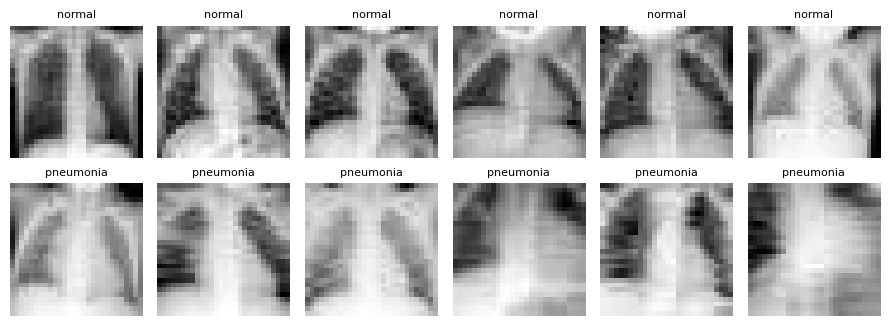

In [15]:
if pneu is not None:
    fig, axes = plt.subplots(2, 6, figsize=(9, 3.4))
    imgs, labels = pneu["train_images"], pneu["train_labels"].ravel()
    for row, cls in enumerate([0, 1]):
        idx = np.where(labels == cls)[0][:6]
        for ax, i in zip(axes[row], idx):
            ax.imshow(imgs[i], cmap="gray")
            ax.set_title("normal" if cls == 0 else "pneumonia", fontsize=8)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

28×28 的解析度遠低於臨床判讀所需，這份資料只適合拿來學神經網路的概念。

### 5.1 建立與訓練全連接網路
把每張 28×28 的圖攤平成 784 個數字，除以 255 縮放到 0～1，接上兩層 ReLU 隱藏層與一個 sigmoid 輸出。
加入 Dropout（訓練時隨機關掉部分神經元）與 EarlyStopping（驗證損失連續 5 個 epoch 沒進步就停，並還原最佳權重）防止過擬合。

In [16]:
hist = None
if keras is not None and pneu is not None:
    keras.utils.set_random_seed(RS)

    def prep(split):
        Xs = pneu[f"{split}_images"].reshape(-1, 28 * 28).astype("float32") / 255.0
        ys = pneu[f"{split}_labels"].ravel().astype("float32")
        return Xs, ys

    Xp_tr, yp_tr = prep("train")
    Xp_va, yp_va = prep("val")
    Xp_te, yp_te = prep("test")

    model = keras.Sequential([
        keras.Input(shape=(28 * 28,)),
        keras.layers.Dense(128, activation="relu"),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3),
                  loss="binary_crossentropy",
                  metrics=["accuracy", keras.metrics.AUC(name="auc")])
    model.summary()

    hist = model.fit(Xp_tr, yp_tr, validation_data=(Xp_va, yp_va),
                     epochs=30, batch_size=64, verbose=2,
                     callbacks=[keras.callbacks.EarlyStopping(
                         monitor="val_loss", patience=5, restore_best_weights=True)])
else:
    print("Skipped: Keras or the dataset is not available.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,801 (425.00 KB)

 Trainable params: 108,801 (425.00 KB)

 Non-trainable params: 0 (0.00 B)

...

74/74 - 0s - 1ms/step - accuracy: 0.9352 - auc: 0.9779 - loss: 0.1625 - val_accuracy: 0.9504 - val_auc: 0.9797 - val_loss: 0.1566


Epoch 12/30


74/74 - 0s - 1ms/step - accuracy: 0.9376 - auc: 0.9802 - loss: 0.1557 - val_accuracy: 0.9523 - val_auc: 0.9847 - val_loss: 0.1445


Epoch 13/30


74/74 - 0s - 1ms/step - accuracy: 0.9397 - auc: 0.9798 - loss: 0.1533 - val_accuracy: 0.9504 - val_auc: 0.9797 - val_loss: 0.1509


每一行是一個 epoch：`loss`／`accuracy` 是訓練集，`val_` 開頭的是驗證集。batch_size=64 表示每看 64 張圖就更新一次權重。

### 5.2 學習曲線：訓練 vs 驗證

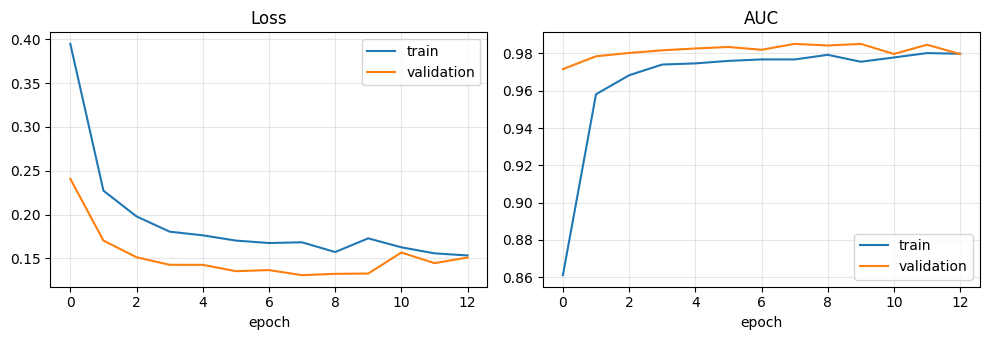

In [17]:
if hist is not None:
    h = hist.history
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    axes[0].plot(h["loss"], label="train")
    axes[0].plot(h["val_loss"], label="validation")
    axes[0].set_title("Loss")
    axes[1].plot(h["auc"], label="train")
    axes[1].plot(h["val_auc"], label="validation")
    axes[1].set_title("AUC")
    for ax in axes:
        ax.set_xlabel("epoch")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Skipped.")

訓練損失持續下降、驗證損失卻停住甚至回升時，就是過擬合開始的訊號；EarlyStopping 會把權重還原到驗證損失最低的那一刻。

### 5.3 在測試集上評估
最後才碰測試集。除了準確率，也用臨床熟悉的敏感度、特異度來看。

In [18]:
if hist is not None:
    p_te = model.predict(Xp_te, verbose=0).ravel()
    pred = (p_te > 0.5).astype(int)
    tn, fp, fn, tp = confusion_matrix(yp_te, pred).ravel()
    print(f"test accuracy : {(tp + tn) / len(yp_te):.3f}")
    print(f"test AUC      : {roc_auc_score(yp_te, p_te):.3f}")
    print(f"sensitivity   : {tp / (tp + fn):.3f}  (pneumonia correctly flagged)")
    print(f"specificity   : {tn / (tn + fp):.3f}  (normal correctly cleared)")
    print(f"majority-class baseline accuracy: {np.mean(yp_te == 1):.3f}")
else:
    print("Skipped.")

test accuracy : 0.829
test AUC      : 0.916
sensitivity   : 0.982  (pneumonia correctly flagged)
specificity   : 0.573  (normal correctly cleared)
majority-class baseline accuracy: 0.625


典型結果：AUC 約 0.9 左右，敏感度高、特異度明顯較低——模型傾向把正常的片子也判成肺炎（訓練資料肺炎多）。
數字會因版本與硬體略有不同。請記得：這是 28×28 小圖、單一醫學中心來源、未經外部驗證的教學結果，不能拿來推論臨床表現。

## 6. 動手試試
1. 把第 3.1 節的 `hidden_layer_sizes` 改成 `(2,)` 或 `(256, 256, 256)`，觀察 `n_iter_` 與測試準確率怎麼變。
2. 在第 3.1 節加上 `early_stopping=True`，看看 `n_iter_` 與準確率——理解為什麼本章建議入門時不要開它。
3. 第 5.1 節把 Dropout 拿掉、`patience` 改成 30，重新畫學習曲線，看訓練與驗證曲線是否拉得更開。
4. 第 5.3 節把判斷閾值 0.5 改成 0.8，敏感度與特異度如何交換？